# Generic Greedy Implementation

In [14]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
import numpy as np

from testdata import diblock_mvn_sample
x_4_100 = diblock_mvn_sample(100, seed=0)
y_4_100 = np.random.default_rng(seed=0).normal(size=100)

x_4_200 = diblock_mvn_sample(200, seed=0)
y_4_200 = np.random.default_rng(seed=0).normal(size=200)

x_4_400 = diblock_mvn_sample(400, seed=0)
y_4_400 = np.random.default_rng(seed=0).normal(size=400)

x_4_800 = diblock_mvn_sample(800, seed=0)
y_4_800 = np.random.default_rng(seed=0).normal(size=800)


## Baseline: Dedicated Greedy for Weighted Support

\begin{equation*}
\mathcal{O}(\boldsymbol{q}) = \boldsymbol{q}^T\boldsymbol{w}
\end{equation*}

In [5]:
import numpy as np
from numba import njit
from numba.experimental import jitclass
from numba.types import int64, float64
from optikon import Propositionalization

### Utility ###
###############

@njit
def argsort_columns(x):
    n, p = x.shape
    out = np.empty((n, p), dtype=np.int64)
    for j in range(p):
        out[:, j] = np.argsort(x[:, j])
    return out

@njit
def max_weighted_support_greedy(x, y, max_depth=5):
    n, p = x.shape
    orders = argsort_columns(x)
    support = np.ones(n, dtype=np.bool)
    support_count = n

    cum_support_count = 0
    non_separable = 0

    v = np.zeros(max_depth, dtype=np.int64)
    s = np.zeros(max_depth, dtype=np.int64)
    t = np.zeros(max_depth, dtype=np.float64)

    current = np.zeros(p, dtype=np.int64) # cursor buffer for order updates
    
    best_sum = np.sum(y)
    num_cond = 0

    for k in range(1, max_depth+1):
        cum_support_count += support_count
        sum_y = np.sum(y[orders[:support_count, 0]])
        best_j, best_i, best_s = -1, -1, 1
        improvement = False
        for j in range(p):
            sum_left, sum_right = 0, sum_y
            for i in range(support_count - 1): 
                # test splits between x^j_i (last left) and x^j_i+1 (first right)
                y_i = y[orders[i, j]]
                sum_left += y_i
                sum_right -= y_i
                if x[orders[i, j], j]==x[orders[i+1, j], j]:
                    non_separable += 1
                    continue

                if sum_left > best_sum:
                    best_i = i
                    best_j = j
                    best_s = -1
                    best_sum = sum_left
                    improvement = True
                elif sum_right > best_sum:
                    best_i = i
                    best_j = j
                    best_s = 1
                    best_sum = sum_right
                    improvement = True

        if not improvement:
            break

        v[k-1] = best_j
        s[k-1] = best_s
        t[k-1] = best_s*(x[orders[best_i, best_j], best_j] + x[orders[best_i + 1, best_j], best_j]) / 2
        num_cond = k

        if best_s == 1: # lower bound
            support[orders[:best_i+1, best_j]] = False
        else: # upper bound
            support[orders[best_i+1:, best_j]] = False

        current[:] = 0
        for i in range(support_count): # need old support count here
            for j in range(p): # can this loop be vectorised?
                if support[orders[i, j]]:
                    orders[current[j], j] = orders[i, j]
                    current[j] += 1

        if best_s == 1: # lower bound
            support_count = support_count - best_i - 1
        else: # upper bound
            support_count = best_i + 1

    res = Propositionalization(v[:num_cond], t[:num_cond], s[:num_cond])
    return res, best_sum, {'cum_support_count': cum_support_count,
                           'non_separable': non_separable}

res, val, stats = max_weighted_support_greedy(x_4_100, y_4_100)
res.as_conj_str(), val

('x4 <= 0.494 & x1 <= 1.514 & x2 >= -0.140', 21.443390305350473)

## Architecture with Objective Function Objects for Incremental Computation

In [47]:
@jitclass
class WeightedSupport:

    w: float64[:]
    value: float64
    value_removed: float64
    value_remaining: float64

    def __init__(self, w):
        self.w = w
        self.support(np.arange(len(w)))
        self.reset()
        # self.value = np.sum(w)
        # self.value_removed = 0
        # self.value_remaining = self.value

    def support(self, support):
        self.value = np.sum(self.w[support])

    def reset(self):
        self.value_removed = 0
        self.value_remaining = self.value

    def remove(self, i):
        yi = self.w[i]
        self.value_removed += yi
        self.value_remaining -= yi

ws = WeightedSupport(y_4_100)
ws.remove(0)
ws.remove(1)
ws.value_removed

-0.006374642197908592

In [48]:
@njit
def greedy_maximization(x, obj, max_depth=5):
    n, p = x.shape
    orders = argsort_columns(x)
    support = np.ones(n, dtype=np.bool)
    support_count = n

    cum_support_count = 0
    non_separable = 0

    v = np.zeros(max_depth, dtype=np.int64)
    s = np.zeros(max_depth, dtype=np.int64)
    t = np.zeros(max_depth, dtype=np.float64)

    current = np.zeros(p, dtype=np.int64) # cursor buffer for order updates
    
    best_value = obj.value
    num_cond = 0

    for k in range(1, max_depth+1):
        cum_support_count += support_count

        obj.support(orders[:support_count, 0])
        
        best_j, best_i, best_s = -1, -1, 1
        improvement = False
        for j in range(p):

            obj.reset()
            
            for i in range(support_count - 1): 
                # test splits between x^j_i (last left) and x^j_i+1 (first right)
                
                obj.remove(orders[i, j])
                
                if x[orders[i, j], j]==x[orders[i+1, j], j]:
                    non_separable += 1
                    continue

                if obj.value_removed > best_value:
                    best_i = i
                    best_j = j
                    best_s = -1
                    best_value = obj.value_removed
                    improvement = True
                elif obj.value_remaining > best_value:
                    best_i = i
                    best_j = j
                    best_s = 1
                    best_value = obj.value_remaining
                    improvement = True

        if not improvement:
            break

        v[k-1] = best_j
        s[k-1] = best_s
        t[k-1] = best_s*(x[orders[best_i, best_j], best_j] + x[orders[best_i + 1, best_j], best_j]) / 2
        num_cond = k

        if best_s == 1: # lower bound
            support[orders[:best_i+1, best_j]] = False
        else: # upper bound
            support[orders[best_i+1:, best_j]] = False

        current[:] = 0
        for i in range(support_count): # need old support count here
            for j in range(p): # can this loop be vectorised?
                if support[orders[i, j]]:
                    orders[current[j], j] = orders[i, j]
                    current[j] += 1

        if best_s == 1: # lower bound
            support_count = support_count - best_i - 1
        else: # upper bound
            support_count = best_i + 1

    res = Propositionalization(v[:num_cond], t[:num_cond], s[:num_cond])
    return res, best_value, {'cum_support_count': cum_support_count,
                           'non_separable': non_separable}

res, val, stats = greedy_maximization(x_4_100, WeightedSupport(y_4_100))
res.as_conj_str(), val, len(res.support_all(x_4_100))

('x4 <= 0.494 & x1 <= 1.514 & x2 >= -0.140', 21.443390305350473, 44)

## Computational Overhead Test

In [49]:
times_dedicated = np.zeros(4)

r1 = %timeit -o max_weighted_support_greedy(x_4_100, y_4_100)
times_dedicated[0] = r1.best
r2 = %timeit -o max_weighted_support_greedy(x_4_200, y_4_200)
times_dedicated[1] = r2.best
r3 = %timeit -o max_weighted_support_greedy(x_4_400, y_4_400)
times_dedicated[2] = r3.best
r4 = %timeit -o max_weighted_support_greedy(x_4_800, y_4_800)
times_dedicated[3] = r4.best
times_dedicated

6.48 μs ± 42.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
12.6 μs ± 39.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
18.8 μs ± 101 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
34.7 μs ± 708 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


array([6.43495791e-06, 1.24877763e-05, 1.87006496e-05, 3.41417458e-05])

In [50]:
r1 = %timeit -o greedy_maximization(x_4_100, WeightedSupport(y_4_100))
r2 = %timeit -o greedy_maximization(x_4_200, WeightedSupport(y_4_200))
r3 = %timeit -o greedy_maximization(x_4_400, WeightedSupport(y_4_400))
r4 = %timeit -o greedy_maximization(x_4_800, WeightedSupport(y_4_800))

times_generic = np.array([r1.best, r2.best, r3.best, r4.best])
times_generic


9.15 μs ± 47.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
15.5 μs ± 115 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
22 μs ± 108 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
38.1 μs ± 144 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


array([9.06092375e-06, 1.54167842e-05, 2.18684666e-05, 3.79905500e-05])

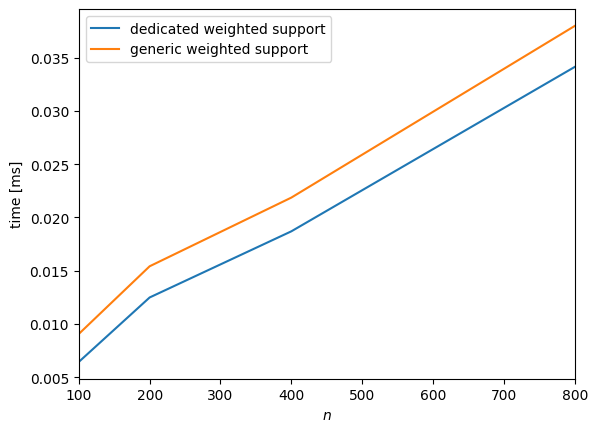

In [51]:
from matplotlib import pyplot as plt

ns = np.array([100, 200, 400, 800])
plt.plot(ns, times_dedicated*1000, label='dedicated weighted support')
plt.plot(ns, times_generic*1000, label='generic weighted support')
plt.ylabel('time [ms]')
plt.xlabel('$n$')
plt.margins(x=0)
plt.legend()
plt.show()

## Relative Weighted Support

\begin{equation*}
\mathcal{O}(\boldsymbol{q}) = \frac{\boldsymbol{q}^T\boldsymbol{w}}{\lambda + \|\boldsymbol{q}\|}
\end{equation*}

In [ ]:
@jitclass
class RelativeWeightedSupport:

    w: float64[:]
    power: float64
    lam: float64
    
    sum_all: float64
    sum_removed: float64
    sum_remaining: float64
    
    count_all: int64
    count_removed: int64
    count_remaining: int64

    value: float64
    value_removed: float64
    value_remaining: float64

    def __init__(self, w, norm=2, lam=0):
        self.w = w
        self.power = 1/norm
        self.lam = lam
        self.support(np.arange(len(w)))
        self.reset()

    def support(self, support):
        self.sum_all = np.sum(self.w[support])
        self.count_all = len(support)
        self.value = self.sum_all / (self.count_all**self.power + self.lam)

    def reset(self):
        self.sum_removed = 0
        self.sum_remaining = self.sum_all
        self.count_removed = 0
        self.count_remaining = self.count_all
        self.value_removed = 0
        self.value_remaining = self.sum_remaining / (self.count_remaining**self.power + self.lam)

    def remove(self, i):
        yi = self.w[i]
        self.sum_removed += yi
        self.sum_remaining -= yi
        self.count_removed += 1
        self.count_remaining -= 1
        self.value_removed = self.sum_removed / (self.count_removed**self.power + self.lam)
        self.value_remaining = self.sum_remaining / (self.count_remaining**self.power + self.lam)

rws = RelativeWeightedSupport(y_4_100, lam=0)
rws.remove(0)
rws.remove(1)
rws.remove(2)
rws.remove(3)
rws.value_removed

0.3694740626992066

In [59]:
res, val, stats = greedy_maximization(x_4_100, RelativeWeightedSupport(y_4_100, 2, lam=10))
res.as_conj_str(), val, len(res.support_all(x_4_100))

('x4 <= -0.383 & x2 >= -0.813 & x4 >= -2.007 & x1 <= 1.514 & x2 >= -0.022',
 1.446626284286675,
 22)

In [54]:
r1 = %timeit -o greedy_maximization(x_4_100, RelativeWeightedSupport(y_4_100))
r2 = %timeit -o greedy_maximization(x_4_200, RelativeWeightedSupport(y_4_200))
r3 = %timeit -o greedy_maximization(x_4_400, RelativeWeightedSupport(y_4_400))
r4 = %timeit -o greedy_maximization(x_4_800, RelativeWeightedSupport(y_4_800))

times_generic_rws = np.array([r1.best, r2.best, r3.best, r4.best])
times_generic_rws

19.2 μs ± 116 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
30.6 μs ± 234 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
37.7 μs ± 128 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
74.5 μs ± 308 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


array([1.90373329e-05, 3.03923000e-05, 3.75159500e-05, 7.39640042e-05])

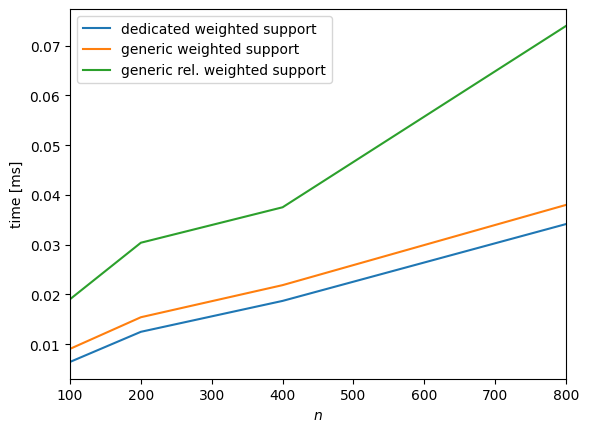

In [55]:
plt.plot(ns, times_dedicated*1000, label='dedicated weighted support')
plt.plot(ns, times_generic*1000, label='generic weighted support')
plt.plot(ns, times_generic_rws*1000, label='generic rel. weighted support')
plt.ylabel('time [ms]')
plt.xlabel('$n$')
plt.margins(x=0)
plt.legend()
plt.show()

## Normalised Weighted Support

\begin{equation*}
\mathcal{O}(\boldsymbol{q}) = \frac{\boldsymbol{q}^T\boldsymbol{w}}{\lambda + \sqrt{\boldsymbol{q}^T\boldsymbol{u}}}
\end{equation*}

In [60]:
@jitclass
class NormalisedWeightedSupport:

    w: float64[:]
    u: float64[:]
    power: float64
    lam: float64
    
    sum_w_all: float64
    sum_w_removed: float64
    sum_w_remaining: float64
    
    sum_u_all: int64
    sum_u_removed: int64
    sum_u_remaining: int64

    value: float64
    value_removed: float64
    value_remaining: float64

    def __init__(self, w, u=None, norm=2, lam=0):
        self.w = w
        self.u = u if u is not None else np.ones(len(w))
        self.power = 1/norm
        self.lam = lam
        self.support(np.arange(len(w)))
        self.reset()

    def support(self, support):
        self.sum_w_all = np.sum(self.w[support])
        self.sum_u_all = np.sum(self.u[support])
        self.value = self.sum_w_all / (self.sum_u_all**self.power + self.lam)

    def reset(self):
        self.sum_w_removed = 0
        self.sum_w_remaining = self.sum_w_all
        self.sum_u_removed = 0
        self.sum_u_remaining = self.sum_u_all
        self.value_removed = 0
        self.value_remaining = self.sum_w_remaining / (self.sum_u_remaining**self.power + self.lam)

    def remove(self, i):
        wi = self.w[i]
        ui = self.u[i]
        self.sum_w_removed += wi
        self.sum_w_remaining -= wi
        self.sum_u_removed += ui
        self.sum_u_remaining -= ui
        self.value_removed = self.sum_w_removed / (self.sum_u_removed**self.power + self.lam)
        self.value_remaining = self.sum_w_remaining / (self.sum_u_remaining**self.power + self.lam)



In [61]:
res, val, stats = greedy_maximization(x_4_100, NormalisedWeightedSupport(y_4_100, norm=2, lam=10))
res.as_conj_str(), val, len(res.support_all(x_4_100))

('x4 <= -0.383 & x2 >= -0.813 & x4 >= -2.007 & x1 <= 1.514 & x2 >= -0.022',
 1.446626284286675,
 22)

In [62]:
r1 = %timeit -o greedy_maximization(x_4_100, NormalisedWeightedSupport(y_4_100))
r2 = %timeit -o greedy_maximization(x_4_200, NormalisedWeightedSupport(y_4_200))
r3 = %timeit -o greedy_maximization(x_4_400, NormalisedWeightedSupport(y_4_400))
r4 = %timeit -o greedy_maximization(x_4_800, NormalisedWeightedSupport(y_4_800))

times_generic_rws_from_nws = np.array([r1.best, r2.best, r3.best, r4.best])
times_generic_rws_from_nws

21.4 μs ± 330 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
33.7 μs ± 305 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
40.6 μs ± 188 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
79.8 μs ± 445 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


array([2.08580083e-05, 3.34737542e-05, 4.02549833e-05, 7.90377084e-05])

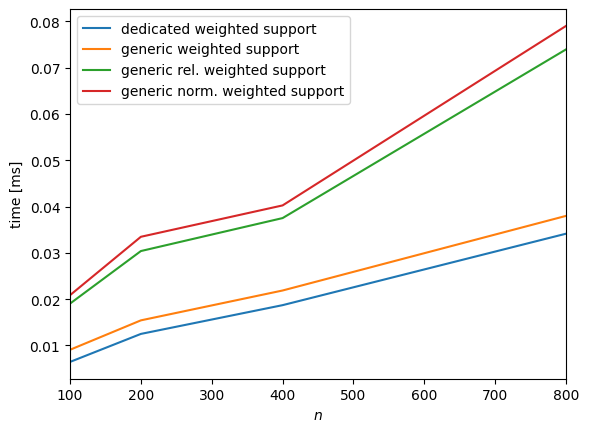

In [63]:
plt.plot(ns, times_dedicated*1000, label='dedicated weighted support')
plt.plot(ns, times_generic*1000, label='generic weighted support')
plt.plot(ns, times_generic_rws*1000, label='generic rel. weighted support')
plt.plot(ns, times_generic_rws_from_nws*1000, label='generic norm. weighted support')
plt.ylabel('time [ms]')
plt.xlabel('$n$')
plt.margins(x=0)
plt.legend()
plt.show()